# Multi-Model Training & Evaluation Pipeline

This notebook trains and evaluates multiple models on a tabular dataset. Models included:

- SVM (RBF)
- Random Forest
- ANN (2-layer)
- ANN (3-layer)
- K-Nearest Neighbors (KNN)
- Gradient Boosting
- XGBoost
- CNN (1D for tabular data)

**Dataset files (expected):** `ds_34_x_train.csv`, `ds_34_y_train.csv`, `ds_34_x_test.csv`, `ds_34_y_test.csv`.

Run the cells in order. Save the notebook after running to keep the trained models saved to disk.

---


## 1) Setup and Imports
Install any missing packages (e.g., xgboost, tensorflow) in your environment before running. The cell below imports all required libraries.

In [1]:
# Imports
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
import os
print("imports done")


imports done


## 2) Load Dataset
Make sure the four CSV files are in the same folder as this notebook or provide full paths. The labels should be 1D arrays (one column).

In [2]:
# Load dataset (adjust paths if needed)
x_train = pd.read_csv("ds_34_x_train.csv").iloc[:, 10:].values
y_train = pd.read_csv("ds_34_y_train.csv").iloc[:, 1].values.ravel()
x_test = pd.read_csv("ds_34_x_test.csv").iloc[:, 10:].values
y_test = pd.read_csv("ds_34_y_test.csv").iloc[:, 1].values.ravel()

y_train = y_train - 1
y_test = y_test - 1

n_classes = len(np.unique(y_train))
n_features = x_train.shape[1]

print("Data loaded successfully!")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape : {x_test.shape}")
print(f"y_test shape : {y_test.shape}")

Data loaded successfully!
x_train shape: (18819, 18)
y_train shape: (18819,)
x_test shape : (8066, 18)
y_test shape : (8066,)


## 3) Helper: evaluation function
This function prints metrics and returns a list row for the summary dataframe.

In [3]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n=== {name} Evaluation ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    
    return [name, acc, prec, rec, f1]

results = []

# 2. ### LOAD YOUR REAL TEST DATA HERE ###
# (Replacing this placeholder data)
print("WARNING: Using placeholder test data. Replace with your actual X_test and y_test.")
X_test = np.random.rand(100, 20) 
y_true_labels = np.random.randint(0, 3, size=100) 
# ### END OF DATA SECTION ###

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 4) Model: SVM (RBF)


=== SVM (RBF) - Test Summary ===
Accuracy  : 0.9474
Precision : 0.9490
Recall    : 0.9474
F1 Score  : 0.9474


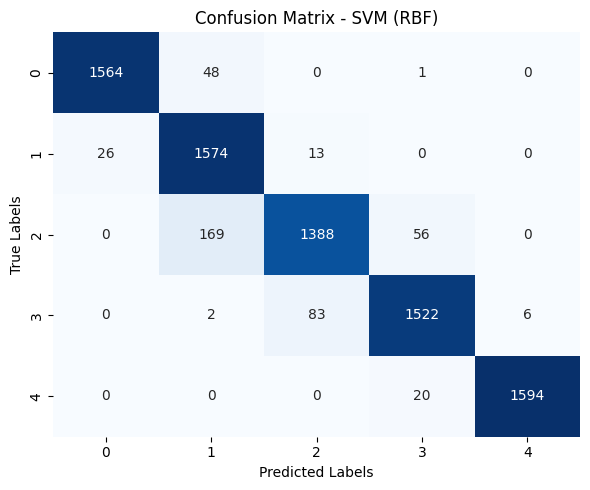

In [5]:
# Define and train the model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(x_train, y_train)

# Predictions on test data
y_pred = svm_model.predict(x_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Save model
os.makedirs("specter_models", exist_ok=True)
pickle.dump(svm_model, open("specter_models/svm_rbf_model_s.pkl", "wb"))

# Textual Summary
print("\n=== SVM (RBF) - Test Summary ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - SVM (RBF)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

# Append to results
results.append(["SVM (RBF)", accuracy, precision, recall, f1])

## 5) Model: Random Forest


=== Random Forest - Test Summary ===
Accuracy  : 0.9830
Precision : 0.9831
Recall    : 0.9830
F1 Score  : 0.9830


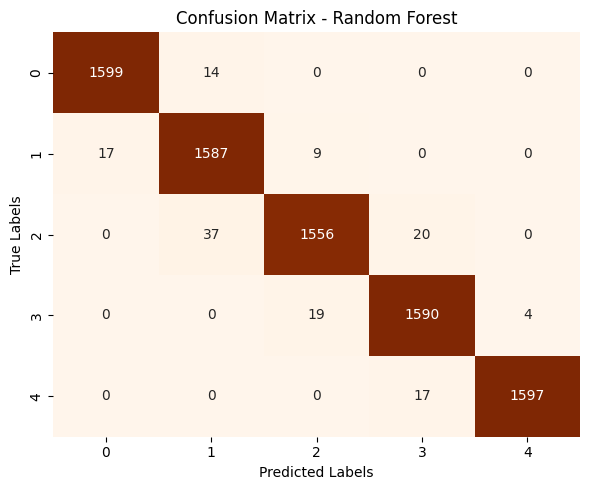

In [6]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

# Predict on test data
y_pred = rf_model.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Save model
os.makedirs("specter_models", exist_ok=True)
pickle.dump(rf_model, open("specter_models/random_forest_model_s.pkl", "wb"))

# Textual Summary
print("\n=== Random Forest - Test Summary ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

# Append to results
results.append(["Random Forest", accuracy, precision, recall, f1])

## 6) Model: ANN (2-layer)


Epoch 1/100


589/589 [==============================] - 4s 3ms/step - loss: 0.5338 - accuracy: 0.8024
Epoch 2/100
589/589 [==============================] - 2s 3ms/step - loss: 0.2362 - accuracy: 0.9135
Epoch 3/100
589/589 [==============================] - 2s 4ms/step - loss: 0.1803 - accuracy: 0.9321
Epoch 4/100
589/589 [==============================] - 2s 4ms/step - loss: 0.1561 - accuracy: 0.9396
Epoch 5/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1413 - accuracy: 0.9462
Epoch 6/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1366 - accuracy: 0.9484
Epoch 7/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1246 - accuracy: 0.9533
Epoch 8/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1237 - accuracy: 0.9510
Epoch 9/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1201 - accuracy: 0.9540
Epoch 10/100
589/589 [==============================] - 2s 4ms/step - loss: 0.1162 - acc

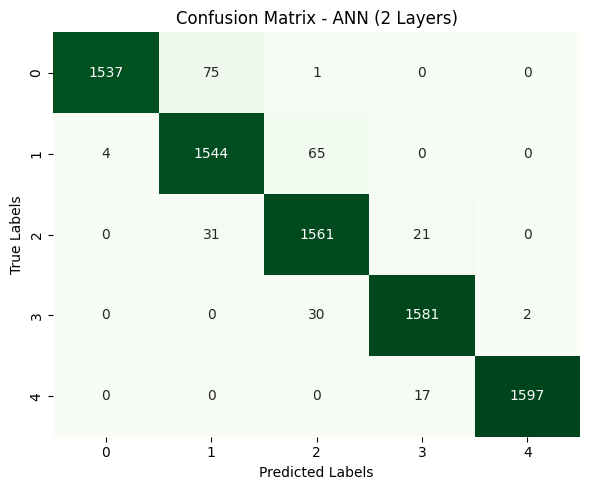

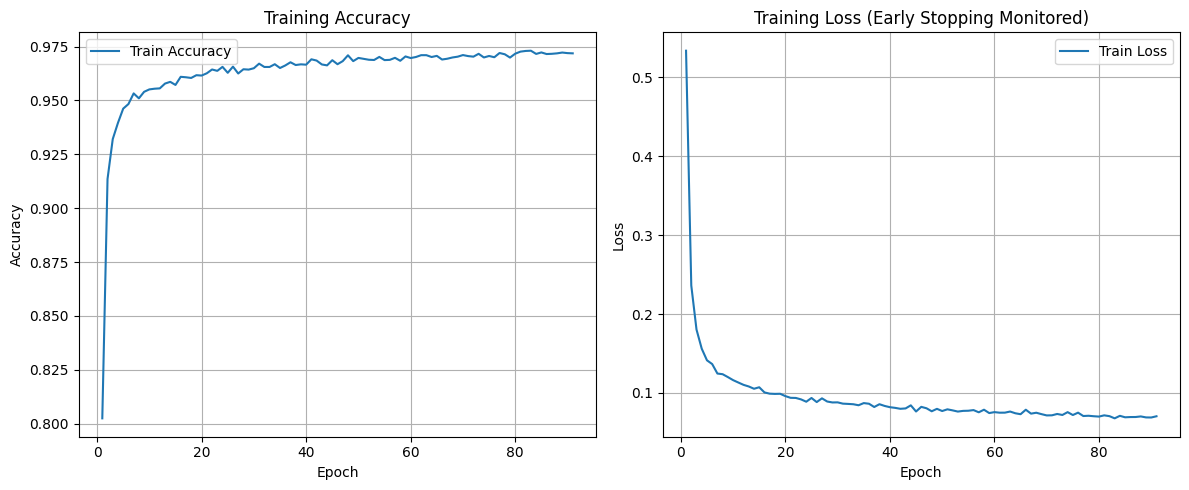

In [7]:
# Split data
n_features = x_train.shape[1]
n_classes = len(np.unique(y_train))

# Define model
ann2 = Sequential([
    Dense(64, activation='relu', input_shape=(n_features,)),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

# Compile model
ann2.compile(optimizer=Adam(learning_rate=0.001),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

# Early stopping (monitor training loss)
early_stop = EarlyStopping(
    monitor='loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Train model (no validation)
history = ann2.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
train_loss, train_acc = ann2.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = ann2.evaluate(x_test, y_test, verbose=0)

# Predictions
y_pred = np.argmax(ann2.predict(x_test), axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Save model
os.makedirs("specter_models", exist_ok=True)
ann2.save("specter_models/ann_2layer_model_s.keras")

# ===========================
#       TEXTUAL SUMMARY
# ===========================
print("\n=== ANN (2 Layers) - Training Summary ===")
print(f"Loss       : {train_loss:.4f}")
print(f"Accuracy   : {train_acc:.4f}")

print("\n=== ANN (2 Layers) - Test Summary ===")
print(f"Loss       : {test_loss:.4f}")
print(f"Accuracy   : {test_acc:.4f}")

print("\n=== ANN (2 Layers) Evaluation ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ===========================
#       VISUALIZATIONS
# ===========================

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - ANN (2 Layers)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

# Accuracy & Loss Curves
epochs_ran = len(history.history['accuracy'])
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs_ran+1), history.history['accuracy'], label='Train Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(1, epochs_ran+1), history.history['loss'], label='Train Loss')
plt.title('Training Loss (Early Stopping Monitored)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 7) Model: ANN (3-layer)

Epoch 1/100
589/589 [==============================] - 3s 3ms/step - loss: 0.4230 - accuracy: 0.8429
Epoch 2/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1948 - accuracy: 0.9242
Epoch 3/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1673 - accuracy: 0.9357
Epoch 4/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1464 - accuracy: 0.9425
Epoch 5/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1429 - accuracy: 0.9436
Epoch 6/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1295 - accuracy: 0.9499
Epoch 7/100
589/589 [==============================] - 1s 2ms/step - loss: 0.1233 - accuracy: 0.9515
Epoch 8/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1197 - accuracy: 0.9522
Epoch 9/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1168 - accuracy: 0.9531
Epoch 10/100
589/589 [==============================] - 2s 3ms/step - loss: 0.1110 - accura

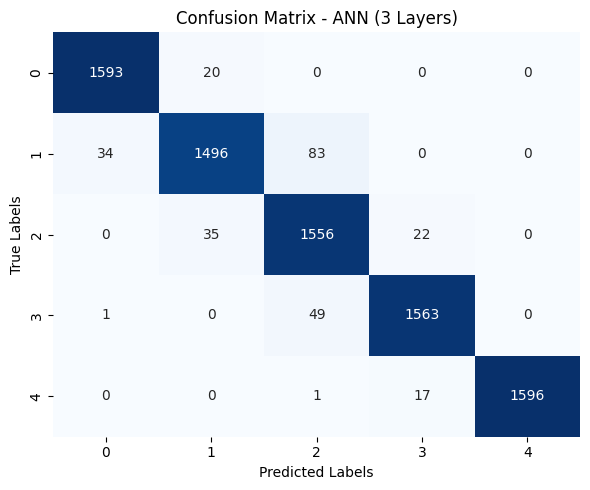

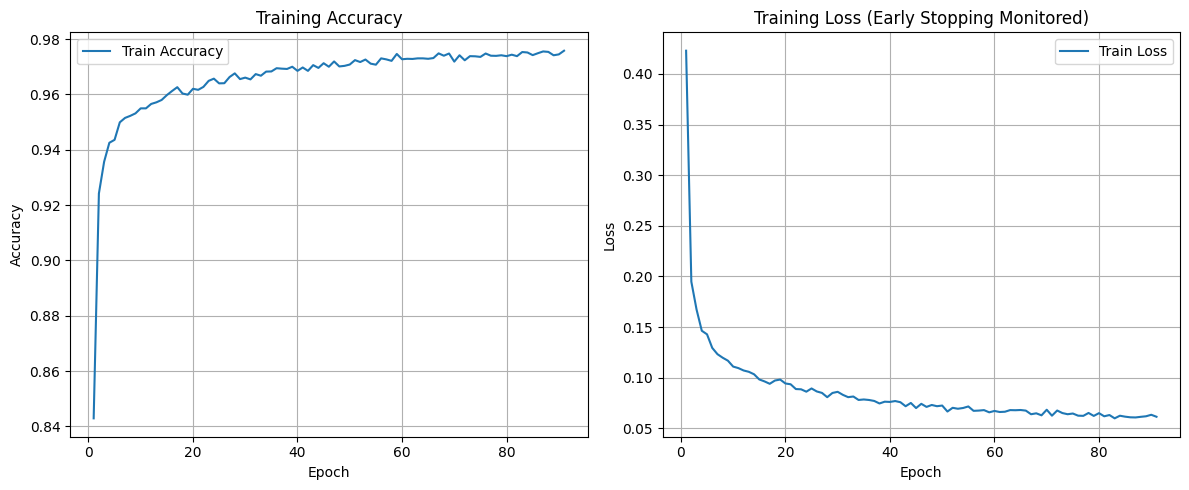

In [8]:
# Features & classes
n_features = x_train.shape[1]
n_classes = len(np.unique(y_train))

# Define model
ann3 = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

# Compile model
ann3.compile(optimizer=Adam(learning_rate=0.001),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

# Early stopping (monitor training loss)
early_stop = EarlyStopping(
    monitor='loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Train
history = ann3.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate sets
train_loss, train_acc = ann3.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = ann3.evaluate(x_test, y_test, verbose=0)

# Predictions
y_pred = np.argmax(ann3.predict(x_test), axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Create directory and save model
os.makedirs("specter_models", exist_ok=True)
ann3.save("specter_models/ann_3layer_model_s.keras")

# ===========================
#       TEXTUAL SUMMARY
# ===========================
print("\n=== ANN (3 Layers) - Training Summary ===")
print(f"Loss       : {train_loss:.4f}")
print(f"Accuracy   : {train_acc:.4f}")

print("\n=== ANN (3 Layers) - Test Summary ===")
print(f"Loss       : {test_loss:.4f}")
print(f"Accuracy   : {test_acc:.4f}")

print("\n=== ANN (3 Layers) Evaluation ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ===========================
#       VISUALIZATIONS
# ===========================

# 1️ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - ANN (3 Layers)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

# 2️ Accuracy & Loss Curves
epochs_ran = len(history.history['accuracy'])
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs_ran+1), history.history['accuracy'], label='Train Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(1, epochs_ran+1), history.history['loss'], label='Train Loss')
plt.title('Training Loss (Early Stopping Monitored)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 8) Model: K-Nearest Neighbors (KNN)


=== KNN Evaluation ===
Accuracy  : 0.9737
Precision : 0.9740
Recall    : 0.9737
F1 Score  : 0.9738

=== KNN Classifier Evaluation ===
Accuracy  : 0.9737
Precision : 0.9740
Recall    : 0.9737
F1 Score  : 0.9738


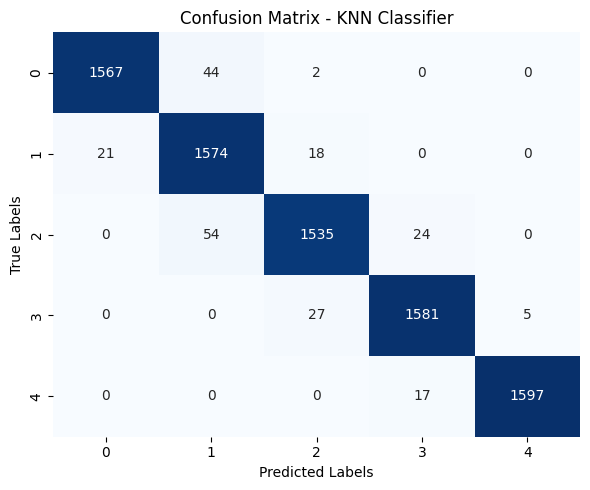

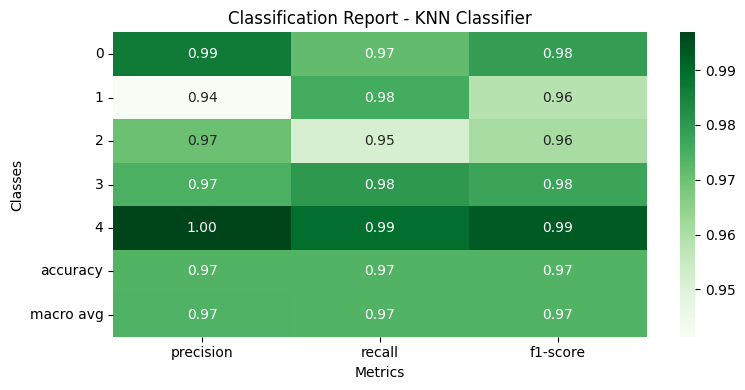

In [9]:
# Train model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

# Predict
y_pred = knn.predict(x_test)

# Create directory (fixed typo: spector → specter)
os.makedirs("specter_models", exist_ok=True)

# Save model
with open(os.path.join("specter_models", "knn_model_s.pkl"), "wb") as f:
    pickle.dump(knn, f)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Append results
results.append(evaluate_model("KNN", y_test, y_pred))

# ===========================
#       TEXTUAL SUMMARY
# ===========================
print("\n=== KNN Classifier Evaluation ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ===========================
#       VISUALIZATIONS
# ===========================

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - KNN Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

# Classification Report (heatmap)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Greens", fmt=".2f")
plt.title("Classification Report - KNN Classifier")
plt.ylabel("Classes")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

## 9) Model: Gradient Boosting


=== Gradient Boost Evaluation ===
Accuracy  : 0.9784
Precision : 0.9785
Recall    : 0.9784
F1 Score  : 0.9784

=== Gradient Boosting Classifier Evaluation ===
Accuracy  : 0.9784
Precision : 0.9785
Recall    : 0.9784
F1 Score  : 0.9784


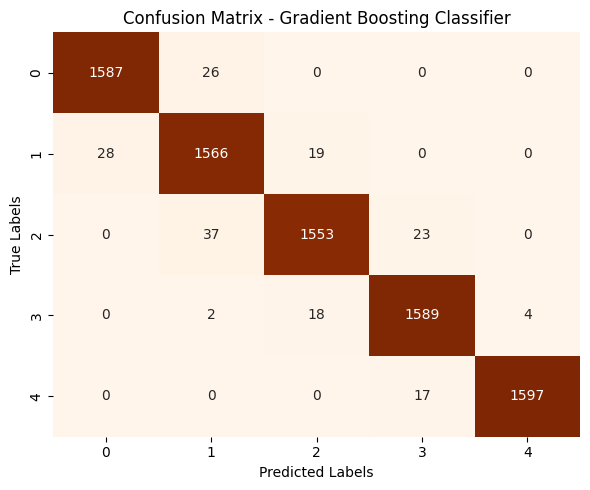

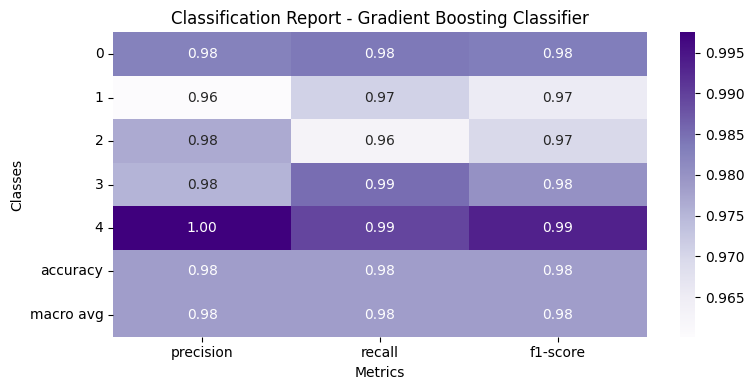

In [10]:
from sklearn.preprocessing import LabelEncoder
# Encode target labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Train model
gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train, y_train)

# Predict
y_pred = gb.predict(x_test)

# Create directory (fixed typo: spector → specter)
os.makedirs("specter_models", exist_ok=True)

# Save model
with open(os.path.join("specter_models", "gradient_boost_model_s.pkl"), "wb") as f:
    pickle.dump(gb, f)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Append results
results.append(evaluate_model("Gradient Boost", y_test, y_pred))

# ===========================
#       TEXTUAL SUMMARY
# ===========================
print("\n=== Gradient Boosting Classifier Evaluation ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ===========================
#       VISUALIZATIONS
# ===========================

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("Confusion Matrix - Gradient Boosting Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

# Classification Report (heatmap)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Purples", fmt=".2f")
plt.title("Classification Report - Gradient Boosting Classifier")
plt.ylabel("Classes")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# Accuracy vs Other Metrics Bar Plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

## 10) Model: XGBoost

D:\food spoilage\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:14:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost Evaluation ===
Accuracy  : 0.9830
Precision : 0.9831
Recall    : 0.9830
F1 Score  : 0.9830

=== XGBoost Classifier Evaluation ===
Accuracy  : 0.9830
Precision : 0.9831
Recall    : 0.9830
F1 Score  : 0.9830


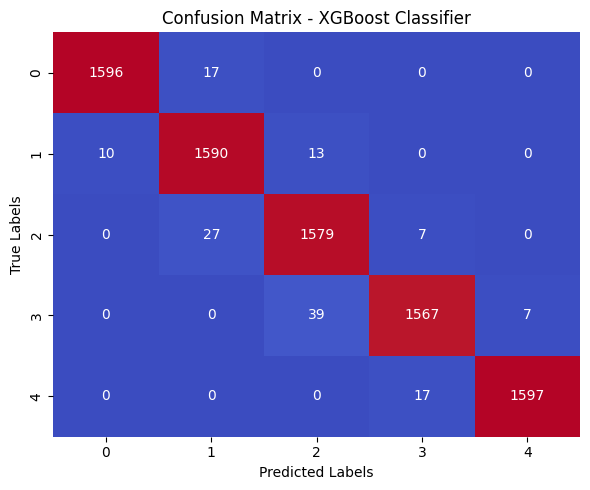

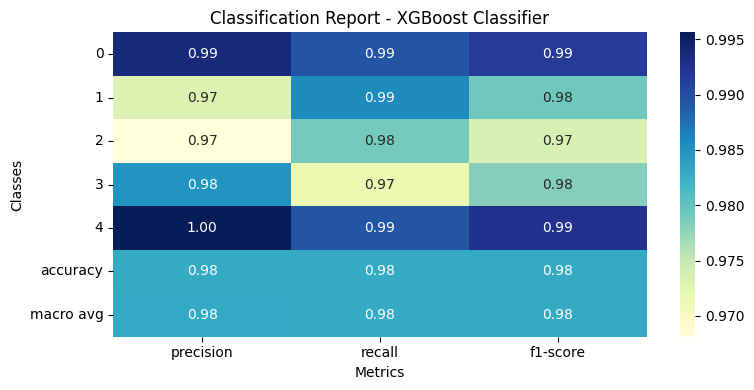

In [11]:
# Train model
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(x_train, y_train)

# Predict
y_pred = xgb.predict(x_test)

# Create directory (fix typo: spector → specter)
os.makedirs("specter_models", exist_ok=True)

# Save model
with open(os.path.join("specter_models", "xgboost_model_s.pkl"), "wb") as f:
    pickle.dump(xgb, f)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Append results
results.append(evaluate_model("XGBoost", y_test, y_pred))

# ===========================
#       TEXTUAL SUMMARY
# ===========================
print("\n=== XGBoost Classifier Evaluation ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ===========================
#       VISUALIZATIONS
# ===========================

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.title("Confusion Matrix - XGBoost Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

# Classification Report (heatmap)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report - XGBoost Classifier")
plt.ylabel("Classes")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# Accuracy vs Other Metrics Bar Plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

## 11) Model: CNN (1D for tabular data)
We reshape data to (samples, timesteps, features) with features as timesteps and 1 channel.

x_train_cnn shape: (18819, 18, 1)
x_test_cnn shape: (8066, 18, 1)

Epoch 1/100
589/589 [==============================] - 4s 5ms/step - loss: 0.4940 - accuracy: 0.8034
Epoch 2/100
589/589 [==============================] - 3s 5ms/step - loss: 0.2382 - accuracy: 0.9080
Epoch 3/100
589/589 [==============================] - 3s 5ms/step - loss: 0.1856 - accuracy: 0.9273
Epoch 4/100
589/589 [==============================] - 3s 5ms/step - loss: 0.1586 - accuracy: 0.9371
Epoch 5/100
589/589 [==============================] - 3s 5ms/step - loss: 0.1455 - accuracy: 0.9437
Epoch 6/100
589/589 [==============================] - 3s 5ms/step - loss: 0.1463 - accuracy: 0.9423
Epoch 7/100
589/589 [==============================] - 3s 5ms/step - loss: 0.1306 - accuracy: 0.9478
Epoch 8/100
589/589 [==============================] - 3s 5ms/step - loss: 0.1279 - accuracy: 0.9483
Epoch 9/100
589/589 [==============================] - 3s 5ms/step - loss: 0.1280 - accuracy: 0.9521
Epoch 10/100
589/589 [==

D:\food spoilage\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



=== CNN Evaluation ===
Accuracy  : 0.9747
Precision : 0.9750
Recall    : 0.9747
F1 Score  : 0.9747

=== CNN Classifier Evaluation ===
Accuracy  : 0.9747
Precision : 0.9750
Recall    : 0.9747
F1 Score  : 0.9747


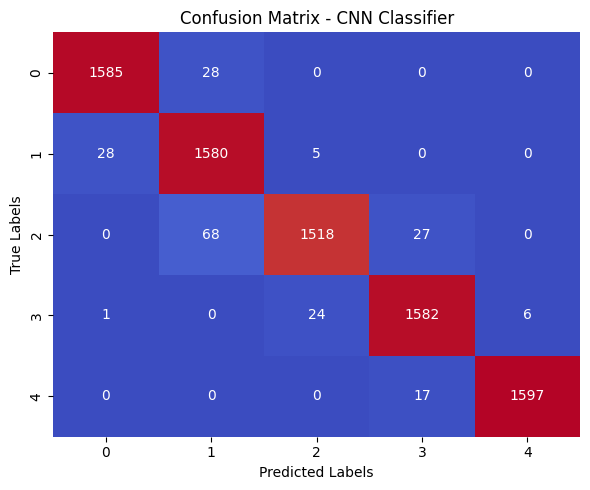

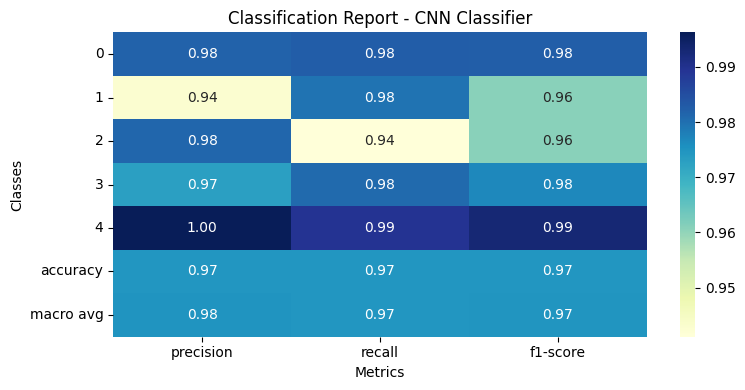

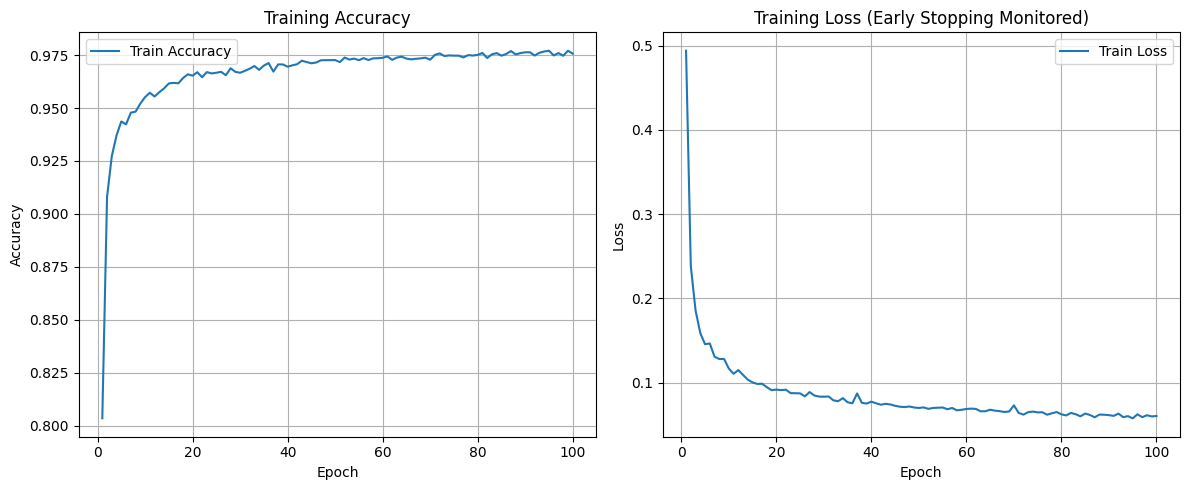

In [12]:
# Prepare data for 1D CNN
x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn = np.expand_dims(x_test, axis=-1)

print("x_train_cnn shape:", x_train_cnn.shape)
print("x_test_cnn shape:", x_test_cnn.shape)

# Define model
cnn = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(x_train_cnn.shape[1], 1)),
    MaxPooling1D(2),
    Conv1D(32, 3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(n_classes, activation='softmax')
])

# Compile model
cnn.compile(optimizer=Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Early stopping (monitor training loss)
early_stop = EarlyStopping(
    monitor='loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Train model with early stopping
history = cnn.fit(
    x_train_cnn, y_train,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predict
y_pred = np.argmax(cnn.predict(x_test_cnn), axis=1)

# Create directory
os.makedirs("specter_models", exist_ok=True)

# Save model
cnn.save(os.path.join("specter_models", "cnn_model_s.h5"))

# Evaluate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Append results
results.append(evaluate_model("CNN", y_test, y_pred))

# ===========================
#       TEXTUAL SUMMARY
# ===========================
print("\n=== CNN Classifier Evaluation ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ===========================
#       VISUALIZATIONS
# ===========================

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.title("Confusion Matrix - CNN Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

# Classification Report (heatmap)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report - CNN Classifier")
plt.ylabel("Classes")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# Accuracy & Loss Curves
epochs_ran = len(history.history['accuracy'])
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs_ran+1), history.history['accuracy'], label='Train Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(1, epochs_ran+1), history.history['loss'], label='Train Loss')
plt.title('Training Loss (Early Stopping Monitored)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Performance Bar Plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]